# 01 — Exploratory Data Analysis
Dataset: APTOS 2019 Blindness Detection
Goals: download, class balance, image quality, sample viz, create train/val/test splits.

## 1. Download the dataset
1. kaggle.com/settings → Create New API Token → downloads kaggle.json
2. Place at ~/.kaggle/kaggle.json (or C:\Users\<you>\.kaggle\kaggle.json on Windows)
3. pip install kaggle (already in requirements.txt)

In [1]:
import os
from pathlib import Path

RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

zip_path = RAW_DIR / "aptos2019-blindness-detection.zip"

if not zip_path.exists():
    os.system(f"kaggle competitions download -c aptos2019-blindness-detection -p {RAW_DIR}")
else:
    print("Zip already downloaded, skipping.")

In [2]:
import zipfile

if not (RAW_DIR / "train.csv").exists():
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(RAW_DIR)
    print("Extracted.")
else:
    print("Already extracted, skipping.")

print(list(RAW_DIR.iterdir())[:10])

Extracted.
[WindowsPath('../data/raw/aptos2019-blindness-detection.zip'), WindowsPath('../data/raw/sample_submission.csv'), WindowsPath('../data/raw/test.csv'), WindowsPath('../data/raw/test_images'), WindowsPath('../data/raw/train.csv'), WindowsPath('../data/raw/train_images')]


In [3]:
import pandas as pd

df = pd.read_csv(RAW_DIR / "train.csv")
print(f"Total labeled images: {len(df)}")
df.head()

Total labeled images: 3662


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


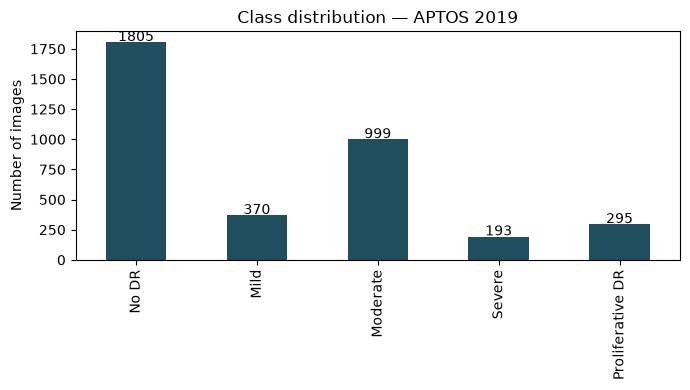

No DR               1805
Mild                 370
Moderate             999
Severe               193
Proliferative DR     295
Name: count, dtype: int64

Class imbalance ratio (largest/smallest): 9.4


In [4]:
import matplotlib.pyplot as plt

SEVERITY_LABELS = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

counts = df["diagnosis"].value_counts().sort_index()
counts.index = [SEVERITY_LABELS[i] for i in counts.index]

ax = counts.plot(kind="bar", figsize=(7, 4), color="#1F4E5F")
ax.set_title("Class distribution — APTOS 2019")
ax.set_ylabel("Number of images")
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha="center")
plt.tight_layout()
plt.show()

print(counts)
print()
print("Class imbalance ratio (largest/smallest):", round(counts.max() / counts.min(), 1))

In [5]:
from PIL import Image
import random

sample_ids = df["id_code"].sample(10, random_state=42).tolist()
sizes = []
for img_id in sample_ids:
    img_path = RAW_DIR / "train_images" / f"{img_id}.png"
    with Image.open(img_path) as img:
        sizes.append(img.size)

print("Sample image sizes (width, height):")
for img_id, size in zip(sample_ids, sizes):
    print(f"  {img_id}: {size}")

Sample image sizes (width, height):
  90960ddf4d14: (2048, 1536)
  4e0656629d02: (2588, 1958)
  3b018e8b7303: (2588, 1958)
  55eb405ec71e: (3388, 2588)
  207dd0487264: (1050, 1050)
  1d74c4713e21: (2048, 1536)
  eb175669d789: (819, 614)
  b49b2fac2514: (3388, 2588)
  4a44cc840ebe: (3216, 2136)
  d6283ded6aea: (3216, 2136)


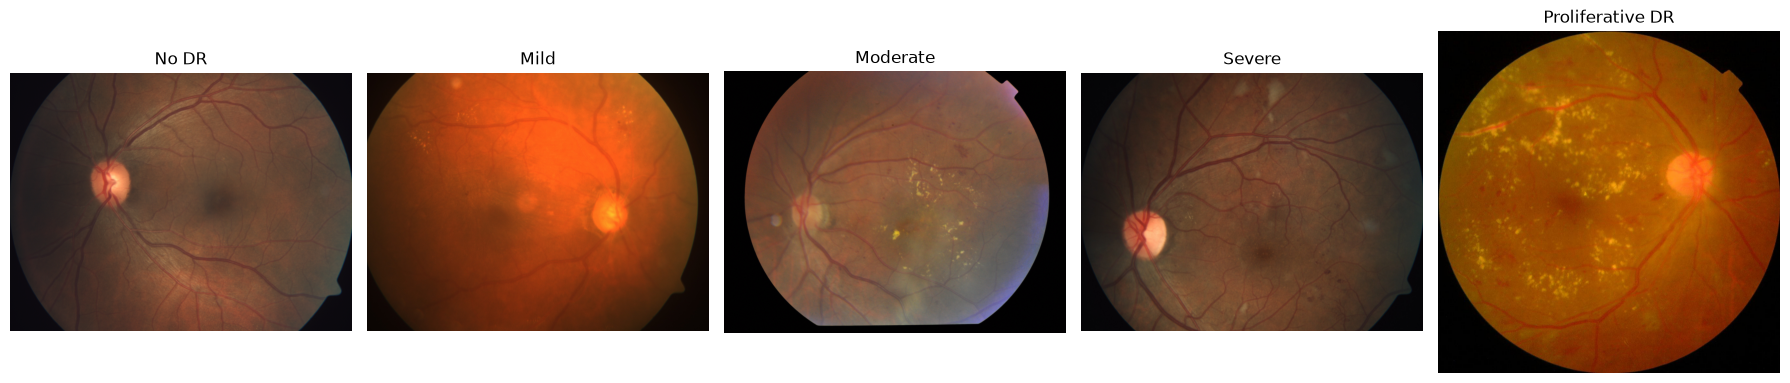

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for severity_idx in range(5):
    subset = df[df["diagnosis"] == severity_idx]
    sample_id = subset["id_code"].sample(1, random_state=1).iloc[0]
    img_path = RAW_DIR / "train_images" / f"{sample_id}.png"

    img = Image.open(img_path)
    axes[severity_idx].imshow(img)
    axes[severity_idx].set_title(SEVERITY_LABELS[severity_idx])
    axes[severity_idx].axis("off")

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

df_renamed = df.rename(columns={"id_code": "image_id"})

train_df, temp_df = train_test_split(
    df_renamed, test_size=0.30, stratify=df_renamed["diagnosis"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["diagnosis"], random_state=42
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)

print("Saved train.csv / val.csv / test.csv to data/processed/")

Train: 2563  Val: 549  Test: 550
Saved train.csv / val.csv / test.csv to data/processed/


In [8]:
for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    ratios = split_df["diagnosis"].value_counts(normalize=True).sort_index().round(3)
    print(f"{name}: {ratios.to_dict()}")

train: {0: 0.493, 1: 0.101, 2: 0.273, 3: 0.053, 4: 0.081}
val: {0: 0.494, 1: 0.1, 2: 0.273, 3: 0.053, 4: 0.08}
test: {0: 0.493, 1: 0.102, 2: 0.273, 3: 0.053, 4: 0.08}


In [ ]:
import shutil

images_src = RAW_DIR / "train_images"
images_dst = PROCESSED_DIR / "images"

if not images_dst.exists():
    shutil.copytree(images_src, images_dst)
    print(f"Copied images to {images_dst}")
else:
    print("Images already present at", images_dst)